<center>
<img src="https://raw.githubusercontent.com/dvgodoy/PyTorch101_ODSC_Europe2020/master/images/linear_dogs.jpg" height="200">

# Семинар 1: введение в PyTorch
</center>

В этом семинаре мы познакомимся с библиотекой [PyTorch.](https://pytorch.org/docs/stable/index.html) Она будет основной на нашем курсе.

На сегодняшний день PyTorch —  это один из самых популярных фреймворков для глубинного обучения. На нём пишут большую часть кода, связанного с нейросетями. Так получилось из-за того, что с ним очень удобно работать. Он очень похож на Numpy, его удобно использовать с GPU, а ещё он умеет считать градиенты за вас.

Концепция библиотеки pytorch — расширить функционал numpy, добавив туда возможность автоматического расчёта градиентов произвольных функций и их композиций, стараясь максимально сохранить привычную семантику.

Устанавливаем библиотеку

```
pip install torch torchvision
```

Дополнительно с торчом выходят `torchvision` и `torchaudio`. В них есть куча разных методов для работы с изображениями и звуком. Обе эти библиотеки тоже можно поставить вместе с торчом. Первая из них уже сегодня нам понадобится.

In [1]:
! pip install torch torchvision

In [2]:
import numpy as np
np.__version__

'2.1.3'

In [3]:
import torch
torch.__version__

'2.11.0+cu128'

In [4]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Тензоры и базовые операции над ними

Базовой единицей фреймворка является структура, которая называется `torch.Tensor`. Tensor - это аналог `numpy.array`, многие методы работы с `torch.Tensor` в точности повторяют методы `numpy array`.

Тензор — это тот тип данных, с которыми работают все нейросети в PyTorch. Матрицы весов — это тензоры. Данные, которые мы подаем на вход сети тоже обязательно должны быть приведены к типу `torch.Tensor`. Ну и выход сети, разумеется, тоже будет иметь тип `torch.Tensor`.

Посмотрим на способы создать тензоры.

In [5]:
# можно создать тензор из листа
x = torch.tensor([1, 2, 3, 4])
x

tensor([1, 2, 3, 4])

In [6]:
# или кортежа tuple
b = ((1,2,3), (4,5,6))
t = torch.tensor(b)
t

tensor([[1, 2, 3],
        [4, 5, 6]])

In [7]:
# или из скаляра
torch.tensor(42)

tensor(42)

In [8]:
torch.tensor(3.142)

tensor(3.1420)

In [9]:
torch.tensor(True)

tensor(True)

In [10]:
# или из массива numpy
a = np.array([[1, 2], [3, 4]])
t = torch.tensor(a)
t

tensor([[1, 2],
        [3, 4]])

`torch.tensor` копирует данные. `torch.from_numpy` создаёт тензор поверх той же памяти: изменения массива видны в тензоре, и наоборот. То же относится к `.numpy()`, о котором ниже.

In [11]:
a = np.array([1, 2, 3])
t_copy, t_view = torch.tensor(a), torch.from_numpy(a)
a[0] = 100
t_copy, t_view

(tensor([1, 2, 3]), tensor([100,   2,   3]))

Строки (str), словари (dict), списки строк — нельзя напрямую конвертировать в тензор

In [12]:
# можно посмотреть тип данных, упакованных в тензор
x.dtype

torch.int64

In [13]:
# можно задать тензор из нулей
torch.zeros(3, 4)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [14]:
# или из единиц, но уже более сложной размерности
torch.ones(3, 4, 2)

tensor([[[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]]])

In [15]:
torch.ones(4, 2)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [16]:
torch.ones(2)

tensor([1., 1.])

In [17]:
# можно сгенерировать тензор из стандартного нормального распределения
torch.randn(2,2)

tensor([[ 1.9759, -1.5569],
        [ 2.0803, -0.0749]])

In [18]:
# тензор с нулями и указанием типа данных
x = torch.zeros(5, 3, dtype=torch.double)
print(x)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)


In [19]:
x.double() # можно поменять тип данных

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

In [20]:
x.int()

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [21]:
# float32 базовый тип данных и не подписывается в выдаче
x.float()

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Все срезы, операции, размерности работают как в numpy. Более того, разработчики PyTorch в последних версиях библиотеки инвестировали массу усилий, чтобы сделать названия функций похожими на numpy. Благодаря этому, если вы знаете одну библиотеку, вы легко можете работать и с другой. Тем не менее, название части функций различается.

In [22]:
x

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

In [23]:
x.shape

torch.Size([5, 3])

In [24]:
# первая строка
x[0]

tensor([0., 0., 0.], dtype=torch.float64)

In [25]:
# все строки первого столбца
x[:,1]

tensor([0., 0., 0., 0., 0.], dtype=torch.float64)

In [26]:
x + 10

tensor([[10., 10., 10.],
        [10., 10., 10.],
        [10., 10., 10.],
        [10., 10., 10.],
        [10., 10., 10.]], dtype=torch.float64)

In [27]:
torch.exp(x)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)

In [28]:
x[x > 0]

tensor([], dtype=torch.float64)

In [29]:
x[x >= 0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=torch.float64)

In [30]:
# если хотим сохранить структуру
y1 = torch.tensor([[0, -1], [3, -4]])
y2 = torch.where(y1 >= 0, y1, y1 * 10)
y2

tensor([[  0, -10],
        [  3, -40]])

In [31]:
y = torch.rand(5, 3)
y

tensor([[0.6548, 0.6565, 0.2532],
        [0.8660, 0.7300, 0.9415],
        [0.8386, 0.1646, 0.8538],
        [0.5526, 0.7530, 0.7575],
        [0.6804, 0.6338, 0.8082]])

In [32]:
x + y # поэлементное сложение

tensor([[0.6548, 0.6565, 0.2532],
        [0.8660, 0.7300, 0.9415],
        [0.8386, 0.1646, 0.8538],
        [0.5526, 0.7530, 0.7575],
        [0.6804, 0.6338, 0.8082]], dtype=torch.float64)

In [33]:
x * y # поэлементное умножение

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

In [34]:
 # матричное умножение
x @ y.T

RuntimeError: expected m1 and m2 to have the same dtype, but got: double != float

In [35]:
x.dtype, y.dtype # матрицы разного типа и умножение упало

(torch.float64, torch.float32)

In [36]:
x.float() @ y.T

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [37]:
# добавили измерение в начало
x.unsqueeze(0).shape

torch.Size([1, 5, 3])

In [38]:
x.unsqueeze(0)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], dtype=torch.float64)

In [39]:
# убрали измерение в начале
x.unsqueeze(0).squeeze(0).shape

torch.Size([5, 3])

In [40]:
x.unsqueeze(0).squeeze(0)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

Мы также можем переводить тензоры назад в numpy или в питоновские листы:

In [41]:
x.numpy()

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

Если у тензора считаются градиенты, до перевода его нужно "снять" с графа вычислений

In [42]:
t = torch.ones(3, requires_grad=True)
arr = t.detach().numpy()  # требуется detach(), иначе будет ошибка
arr

array([1., 1., 1.], dtype=float32)

In [43]:
x.tolist()

[[0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0]]

Одномерные тензоры можно распаковать в числа

In [44]:
x = torch.tensor([3])
x # тензор размера 1x1

tensor([3])

In [45]:
x.item() # число

3

### Задание 1:

- При помощи numpy посчитайте сумму квадратов чисел от 1 до 10000
- Сделайте то же самое с помощью pytorch

In [46]:
# ваш код  ¯\_(⊙︿⊙)_/¯

### Задание 2:

Реализуйте на PyTorch сигмоиду

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

In [47]:
# ваш код  ¯\_(⊙︿⊙)_/¯

### Задание 3:

Реализуйте на PyTorch среднюю квадратичную ошибку.

$$
MSE(\hat y, y) = \frac{1}{n} \cdot \sum_{i=1}^n (\hat y_i - y_i)^2
$$

In [48]:
# ваш код  ¯\_(⊙︿⊙)_/¯

# 2. Работа с GPU

Первое ключевое отличие PyTorch от numpy - лёгкая работа с GPU.

Давайте откроем эту тетрадку в Google Colab и запустим её на видеокарте. Это можно сделать кнопкой `Среда выполнения/сменить среду выполнения`. В списке выберите любую доступную видеокарту.

In [49]:
!nvidia-smi

Wed Sep 16 23:14:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [50]:
x = torch.randn(3, 5)
x.dtype, x.device # тензор лежит на CPU

(torch.float32, device(type='cpu'))

In [51]:
# проверяем доступность GPU
torch.cuda.is_available()

True

In [52]:
torch.cuda.device_count() # число доступных GPU

1

In [53]:
# чтобы отправить вычисления на девайс,
# надо создать переменную с ним
# число - номер видеокарты в компе
torch.device('cuda:0')

device(type='cuda', index=0)

In [54]:
# универсальная строка которую мы будем втыкать во все наши скрипты
# выбирает то что есть
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [55]:
x = torch.randn(4, 4)

x.to(device) # отправить тензор на GPU

tensor([[-1.0631, -0.1589, -0.8897,  0.4760],
        [-0.3554,  0.9658,  1.7083,  1.6211],
        [-0.9139, -0.6924,  0.0908,  0.3333],
        [ 0.1768, -0.3891, -1.0537, -0.7088]], device='cuda:0')

In [56]:
x.cuda() # ещё можно отправить так

tensor([[-1.0631, -0.1589, -0.8897,  0.4760],
        [-0.3554,  0.9658,  1.7083,  1.6211],
        [-0.9139, -0.6924,  0.0908,  0.3333],
        [ 0.1768, -0.3891, -1.0537, -0.7088]], device='cuda:0')

In [57]:
x.cpu() # вернуть назад

tensor([[-1.0631, -0.1589, -0.8897,  0.4760],
        [-0.3554,  0.9658,  1.7083,  1.6211],
        [-0.9139, -0.6924,  0.0908,  0.3333],
        [ 0.1768, -0.3891, -1.0537, -0.7088]])

Обратите внимание, что при изменении device (c GPU на CPU и обратно происходит копирование). Операции между тензорами на разных устройствах невозможны:

ps это супер-важное замечание, ошибка такого типа будет часто всплывать при обучении моделей

In [58]:
x.cuda() + x

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

Сравним скорость работы типичного слоя нейронной сети - матричное умножение + нелинейность на CPU и GPU



In [59]:
def layer(A, B):
    C = A @ B
    C = C ** 2
    return C

In [60]:
A = torch.randn(1000, 1000)
B = torch.randn(1000, 1000)

- µs (микросекунда) = 10⁻⁶ секунды
- ms (миллисекунда) = 10⁻³ секунды

In [61]:
%timeit _ = layer(A, B)

29.8 ms ± 1.73 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [62]:
A_device, B_device = A.to(device), B.to(device)
%timeit _ = layer(A_device, B_device)

598 µs ± 3.86 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Видим, что вычисления на GPU значительно быстрее вычислений на CPU, но мы не учли одну вещь - время копирования данных. Давайте сделаем более честный замер

In [63]:
%timeit _ = layer(A.to(device), B.to(device))

1.91 ms ± 37.9 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Всё ещё выигрываем во времени, но копирование сожрало часть выигрыша.

На GPU делаются сложные вычисления. Все простые операции вроде подготовки данных и логгирования метрик должны происходить на CPU.

Данные обычно предобрабатывают на CPU, затем формируют батчи для обучения и передают на GPU. Сама нейросеть учится на GPU и там хранит свои градиенты и веса.

# 3. Производные да градиенты

Вторая ключевая особенность PyTorch - умение считать градиенты. При создании тензора можно указать, нужно ли считать по нему градиент с помощью параметра `requires_grad`.

Когда `requires_grad=True` мы сообщаем фреймворку, что хотим считать градиенты по этому тензору. Иными словами, у любого тензора, у которого указан данный параметр, будет доступ к цепочке операций и преобразований совершенными с ними. Если эти функции дифференцируемые, то у тензора появляется параметр `.grad`, в котором хранится значение градиента.

PyTorch проходит по всем операциям, которые фигурируют в графе вычислений, и применяет к ним производную сложной функции (на английском пафосно называют это chain rule):

$$ {\partial f(g(x)) \over \partial x} = {\partial f(g(x)) \over \partial g(x)}\cdot {\partial g(x) \over \partial x} $$

Давайте попробуем!

In [64]:
x = torch.randn(3, 3, requires_grad=True)

In [65]:
# пока градиента нет
print(x.grad, '<- gradient')

None <- gradient


In [66]:
y = torch.sum(x * x)
y.backward()

# градиент подъехал
print(x.grad, '<- gradient')

tensor([[ 2.5692,  3.9598, -0.3964],
        [-0.2579, -3.0296, -3.5481],
        [-0.0308, -1.5554,  1.1752]]) <- gradient


Если не предпринимать никаких дополнительных действий, то множественный вызов `.backward()` будет не перезаписывать градиенты тензоров, а складывать их с уже существующим значением (сам граф вычислений каждый раз разрушается).

In [67]:
z = torch.sum(2 * x)
z.backward()

# Заметьте, что ко всем значениям прибавилось 2
print(x.grad, '<- gradient')

tensor([[ 4.5692,  5.9598,  1.6036],
        [ 1.7421, -1.0296, -1.5481],
        [ 1.9692,  0.4446,  3.1752]]) <- gradient


Обычно мы обучаем модель не по одному объекту, а на большой выборке. Вся выборка в память не влезает. Мы прогоняем через нейросеть данные батчами. PyTorch позволяет накапливать градиенты по батчам не помещая в память все данные.

Чтобы считать градиент с нуля, достаточно его удалить или обнулить.

In [68]:
x.grad.zero_()

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

### Кому достаётся `.grad`

`.grad` заполняется только у **листьев** графа — тензоров, созданных руками с `requires_grad=True`. Именно такими будут параметры модели. У промежуточных результатов (активаций) градиент считается, передаётся дальше по цепочке, но не сохраняется — это экономит память.

In [72]:
w = torch.randn(3, requires_grad=True)   # лист: создан руками
h = w * 2                                # не лист: результат операции
h.sum().backward()

w.is_leaf, h.is_leaf, w.grad

(True, False, tensor([2., 2., 2.]))

In [73]:
h.grad

/tmp/ipykernel_924/3830859915.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  h.grad


У `h` поле `.grad` останется `None` (PyTorch ещё и предупредит об этом при обращении). Если градиент по промежуточному тензору всё-таки нужен, до `backward()` вызывают `retain_grad()`.

In [70]:
h = w * 2
h.retain_grad()
h.sum().backward()

h.grad

tensor([1., 1., 1.])

### Давайте сверимся:

Autograd делает ровно то, что мы считали руками на лекции.

Возьмём что-то такое: $f(x_1, x_2, x_3) = x_1^2 (x_2 x_3 - 2 x_1^2)$ в точке $(1, 2, 3)$ — обратный проход дал $\nabla f = (4, 3, 2)$.

In [74]:
x = torch.tensor([1., 2., 3.], requires_grad=True)
f = x[0] ** 2 * (x[1] * x[2] - 2 * x[0] ** 2)
f.backward()

x.grad

tensor([4., 3., 2.])

И сеть $2 \to 2 \to 1$ с ReLU и потерей $L = \frac{1}{2}(\hat y - y)^2$. Нулевая строка в градиенте по $W_1$ — тот самый нейрон, у которого $u_1 < 0$: ReLU выключила его, и на этом объекте его веса не обновятся.

In [75]:
x = torch.tensor([1., 2.])
y = torch.tensor([1.])

W1 = torch.tensor([[0.5, -1.], [1., 0.5]], requires_grad=True)
b1 = torch.tensor([0., -1.], requires_grad=True)
W2 = torch.tensor([[2., -1.]], requires_grad=True)
b2 = torch.tensor([0.5], requires_grad=True)

z = torch.relu(W1 @ x + b1)
y_hat = W2 @ z + b2
loss = 0.5 * (y_hat - y) ** 2
loss.backward()

W2.grad, b2.grad, W1.grad, b1.grad

(tensor([[-0.0000, -1.5000]]),
 tensor([-1.5000]),
 tensor([[0.0000, 0.0000],
         [1.5000, 3.0000]]),
 tensor([0.0000, 1.5000]))

### Задание 4:

Реализуйте расчёт градиента для функции

$$
f(w) = \prod_{i,j} \ln(\ln(w_{ij} + 7))
$$

в точке `w = [[5,10], [1,2]]`

In [ ]:
# ваш код  ¯\_(⊙︿⊙)_/¯

В numpy существует интуитивно понятная функция `.copy()`, но в pytorch функции с таким названием нет! Это связано с тем, что тензоры в pytorch привязаны к графу вычислений, который надо также учитывать при копировании.

`.clone()` копирует тензор и сохраняет его привязку к текущему дереву вычислений.

### Задание 5:

Что будет в переменной `x` в результате выполнения следующего кода? Почему?

In [ ]:
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
y = x
y[2] = torch.ones(3)

print(y)
print('')
print(x)

Как это можно исправить?

In [ ]:
# ваш код  ¯\_(⊙︿⊙)_/¯

Очень часто при копировании тензоров недостаточно сделать только `.clone`, так как мы не хотим сохранять связь с графом вычислений. Например, если мы применим `.clone` к выходу нейросети, то добавим новое ребро в граф вычислений, что повлечёт накладные расходы.

Чтобы отвязать тензор от графа вычислений, используют `.detach()`. Важно: он **не копирует** данные — новый тензор смотрит в ту же память, просто у него `requires_grad=False` и градиент через него не пройдёт. Если нужна именно независимая копия без графа — `x.detach().clone()`.


In [76]:
x = torch.rand(3, requires_grad=True)
x.requires_grad

True

In [77]:
y = x.clone()
y.requires_grad

True

In [78]:
z = x.detach()
z.requires_grad

False

In [79]:
z[0] = 0   # z и x смотрят в одну память
x

tensor([0.0000, 0.9949, 0.9321], requires_grad=True)

### Забавный пример: как положить продакшн?

Когда мы будем учить нейросети, мы будем делать много итераций обучения. В конце каждой мы захотим сохранять значение функции потерь. Если вычислить её для нового батча данных и забыть отвязать от графа вычислений, мы будем таскать за собой весь граф — вместе с данными, от которых он посчитан. Давайте искусственно забудем это сделать и посмотрим, как растёт память GPU. Размеры взяты небольшими, чтобы не уронить сессию; в настоящем обучении это заканчивается `CUDA out of memory`.

In [95]:
w = torch.randn(4000, requires_grad=True, device=device)   # наши веса модели

torch.cuda.reset_peak_memory_stats()
losses = []
for i in range(40):
    x = torch.randn(4000, 4000, device=device)   # пришли свежие данные, 64 MB
    loss = torch.linalg.norm(x @ w)              # как бы посчитали метрику качества
    losses.append(loss)                          # запомнили её — вместе с графом и x

    if (i + 1) % 5 == 0:
        print(f"итерация {i + 1:2d}: занято {torch.cuda.max_memory_allocated() // 2**20} MB")

итерация  5: занято 326 MB
итерация 10: занято 636 MB
итерация 15: занято 946 MB
итерация 20: занято 1256 MB
итерация 25: занято 1566 MB
итерация 30: занято 1876 MB
итерация 35: занято 2186 MB
итерация 40: занято 2496 MB


Отвязать от графа вычислений скаляр можно методом `.item()`. Добавляем его к коду и проблема уходит.

In [96]:
w = torch.randn(4000, requires_grad=True, device=device)

torch.cuda.reset_peak_memory_stats()
losses = []
for i in range(20):
    x = torch.randn(4000, 4000, device=device)
    loss = torch.linalg.norm(x @ w)
    losses.append(loss.item())                   # число, граф и x свободны

    if (i + 1) % 5 == 0:
        print(f"итерация {i + 1:2d}: занято {torch.cuda.max_memory_allocated() // 2**20} MB")

итерация  5: занято 2496 MB
итерация 10: занято 2496 MB
итерация 15: занято 2496 MB
итерация 20: занято 2496 MB


In [97]:
import gc

gc.collect() # собираем мусор

870

# 4. Оптимизация

Итак, PyTorch умеет искать производные, осталось научиться применять его для оптимизации.

Давайте обучим линейную регрессию.

P.S.: раньше тут был датасет boston housing, но кто-то решил, что это неэтично, и датасет удалили почти отовсюду

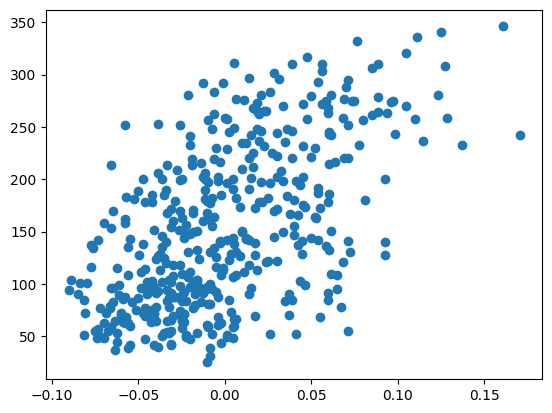

In [98]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()          # 442 пациента, 10 признаков, таргет — прогрессирование болезни за год
feature = diabetes.data[:, 2]       # индекс массы тела (BMI)
target = diabetes.target

plt.scatter(feature, target);

Зададим тензоры для весов. Обучим модель на CPU, чтобы не загромождать код перебрасыванием данных туда-сюда.



In [99]:
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [100]:
w, b

(tensor([-0.8056], requires_grad=True), tensor([-1.7900], requires_grad=True))

In [101]:
# стандартизуем признак: так градиентный спуск сходится быстрее
x = torch.tensor((feature - feature.mean()) / feature.std(), dtype=torch.float32)
y = torch.tensor(target, dtype=torch.float32)

In [102]:
# Наша модель
def linear_regression(x):
    return w * x + b

# Ошибка для модели
def mean_square(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

In [103]:
pred = linear_regression(x)
pred.shape

torch.Size([442])

In [104]:
loss = mean_square(pred, y)
loss

tensor(29695.7422, grad_fn=<MeanBackward0>)

In [105]:
# считаем градиенты
loss.backward()

In [106]:
print("dL/dw = \n", w.grad)
print("dL/db = \n", b.grad)

dL/dw = 
 tensor([-91.9312])
dL/db = 
 tensor([-307.8470])


Обучим модель с помощью градиентного спуска. Прямо как у нас было на курсе машинного обучения, но цикл напишем сами.

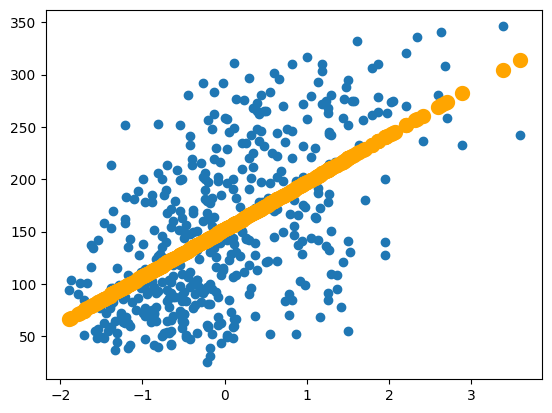

epoch 100, loss = 3890.5


In [107]:
epochs = 100

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

for i in range(epochs):

    y_pred = linear_regression(x)
    loss = mean_square(y_pred, y)

    loss.backward() # считаем градиенты

    with torch.no_grad():
        # делаем шаг градиентного спуска с lr = .05
        w -= 0.05 * w.grad
        b -= 0.05 * b.grad

        # обнуляем градиенты, чтобы на следующем шаге посчитать их с нуля,
        # а не сложить с предыдущими
        w.grad.zero_()
        b.grad.zero_()

    # рисуем картинки
    if (i + 1) % 10 == 0:
        clear_output(True)
        plt.scatter(x.numpy(), y.numpy())
        plt.scatter(x.numpy(), y_pred.detach().numpy(), color='orange', linewidth=5)
        plt.show()
        print(f"epoch {i + 1}, loss = {loss.item():.1f}")


### Задание 6:

Решите задачу

$$
f(w) = \prod_{i,j} \ln(\ln(w_{ij} + 7)) \to \min_{w}
$$

градиентным спуском из точки `w = [[5, 10], [1, 2]]`: сделайте 100 шагов с `lr = 0.1` и выведите значение функции. Затем увеличьте `lr` до 1 и число шагов до 1000. Что происходит и почему?

In [ ]:
# ваш код  ¯\_(⊙︿⊙)_/¯

В этом примере мы написали градиентный спуск руками. На практике нам не придется это делать. К счастью, в PyTorch есть отдельный модуль, который отвечает за оптимизаторы. На него мы посмотрим ниже при обучении своей первой нейросети.

# 5. Менеджеры контекста

Поведением градиента сразу группы тензоров можно управлять с помощью специальных функций, которые вызываются через стандартную семантику питона `with foo():`, где `foo` — одна из трёх функций ниже:

- **Default Mode.** Стандартный режим работы pytorch, в котором управление градиентами происходит через `requires_grad`. Явно его нужно вызывать только внутри других контекстных менеджеров, чтобы временно снова активировать расчёт градиентов (что случается крайне редко) вызовом `torch.enable_grad()`.

- **No grad mode.** Данный режим используется когда в блоке кода нет необходимости вычислять градиенты, что занимает как вычислительные ресурсы, так и дополнительную память. Реализуется вызовом `torch.no_grad()`. Типичная ошибка -- забыть отключить вычисление градиентов при инференсе и забить всю оперативку ими.

- **Inference mode.**  Аналогично No grad mode отключает расчёт градиентов, но кроме того проводит дополнительные оптимизации, что делает вычисления внутри блока кода ещё быстрее. Однако, тензоры, созданные в таком блоке будет невозможно использовать совместно с тензорами, для которых расчёт градиента необходим. Реализуется вызовом `torch.inference_mode()`.

In [108]:
x = torch.rand(3, requires_grad=True)

with torch.no_grad():
    y = x + x

y.requires_grad

False

In [109]:
@torch.no_grad()
def foo(x):
    return x + 2

y = foo(x)
y.requires_grad

False

# 6. Моя первая нейросеть

Для того, чтобы разобраться как обучать нейросетки, нужно освоить три вещи:

1. Как обрабатывать поток данных и пихать его в сетку
2. Как сделать сетку
3. Как написать цикл обучения

## 6.1 Как формировать батчи и пихать их в сетку

С данными помогают работать две абстракции: `Dataset` и `DataLoader`.

`Dataset` умеет выдавать по индексу некоторый элемент и помогает итерироваться по данным. Чтобы работать с данными и применять к ним преобразования, например, аугментации, о которых вы узнаете позже — нужно создать свой класс унаследованный от `torch.utils.data.Dataset`.

У такого класса должно быть два метода:

* `__len__` — возвращает информацию о том, сколько объектов у нас в датасете
* `__getitem__` — возвращает семпл и таргет к нему

Теперь давайте напишем такой сами, в качестве датасета сгенерируем рандомные данные. В следующих семинарах мы обязательно попишем более сложные датасеты.

In [110]:
class RandomDataset(torch.utils.data.Dataset):
    """Our random dataset"""

    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {'sample': torch.tensor(self.x[idx, :], dtype=torch.float), 'target': self.y[idx]}

In [111]:
x = np.random.rand(1000, 5)
y = np.random.rand(1000)

In [112]:
our_dataset = RandomDataset(x, y)

In [113]:
our_dataset.__getitem__(1)

{'sample': tensor([0.7852, 0.9205, 0.4573, 0.2128, 0.6072]),
 'target': np.float64(0.5276167750940625)}

`Dataset` умеет говорить сколько в выборке объектов и брать из неё очередной. Этого мало. Данные хочется как-то видоизменять. Для этого есть такая сущность как `DataLoader`.

Он принимает на вход класс унаследованный от `torch.utils.data.Dataset` и преобразовывает его.

In [114]:
dataloader = torch.utils.data.DataLoader(our_dataset, batch_size=4, shuffle=True)

Здесь:
- `batch_size` — размер батча, на которые даталоадер будет делить данные перед каждой эпохой;
- `shuffle` — если `True`, то перед каждой эпохой и делением на батчи данные будут перемешаны. Shuffle обычно ставится `True` для обучающих данных, и `False` для тестовых.

Итерироваться по данным можно циклом.



In [115]:
for batch in dataloader:
    batch_x = batch['sample']
    batch_y = batch['target']
    break

print('Sample:', batch_x)
print('Target:', batch_y)

Sample: tensor([[0.8944, 0.0892, 0.8235, 0.6291, 0.7427],
        [0.9892, 0.8177, 0.7653, 0.1813, 0.7703],
        [0.5559, 0.1544, 0.7980, 0.7861, 0.4150],
        [0.8562, 0.2449, 0.0219, 0.1093, 0.0082]])
Target: tensor([0.3344, 0.1186, 0.0126, 0.1535], dtype=torch.float64)


Если бы мы написали метод в классе даталоадера чуть иначе:

```
    def __getitem__(self, idx):
        # Возвращаемый результат — (x, y), а не словарь!
        sample = torch.tensor(self.x[idx, :], dtype=torch.float)
        target = torch.tensor(self.y[idx], dtype=torch.float)
        return sample, target
```

мы бы возвращали tuple а не словарь и смогли бы итерироваться по объектам лоадера проще

```
for batch_x, batch_y in dataloader:
```

## 6.2 Нейронная сеть

Есть несколько способов задать нейросеть.

**Способ 1:** задать нейросеть в виде класса, который наследуется от абстрактного класса `torch.nn.Module`. В этот класс завёрнута куча кода, который делает работу с параметрами нейросети на порядок удобнее.

Нам для задания нейросети достаточно определить у класса методы `__init__ `и `forward`.

В методе `__init__ ` обычно прописываются слои и атрибуты сети, а в `forward` — то, как нейросеть будет обрабатывать данные, поданные ей на вход.

In [116]:
from torch import nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self):

      '''
        Конструктор блока. Здесь обычно создают обучаемые параметры и сохраняют переменные,
            определяющие глобальное состояние слоя, а также гиперпараметры
        Блок, может содержать в себе подблоки, которые также были отнаследованы от базового класса torch.nn.Module
      '''
      # Необходимо вызвать конструктор базового класса для корректной работы блока
      super().__init__()
      self.model = nn.Sequential(
          nn.Linear(5, 3),
          nn.ReLU(),
          nn.Linear(3, 1)
        )

    def forward(self, x):
        '''
        Функция, реализующая прямой проход через слой. В процессе вычислений создаётся граф вычислений
            сквозь который выполняется автоматическое дифференцирование.
        '''
        return self.model(x)

Модуль `nn` содержит в себе реализацию большинства слоев, а модуль `nn.functional`—  функций активаций.

In [117]:
model = NeuralNet()  # завели себе нейросеть
model(batch_x)   # получили предсказания модели

tensor([[0.1407],
        [0.1407],
        [0.1407],
        [0.1407]], grad_fn=<AddmmBackward0>)

Градиент по параметру всегда имеет форму самого параметра — иначе шаг `w -= lr * w.grad` было бы не выполнить поэлементно. Размер батча в форму не входит: вклады всех объектов складываются в одну матрицу.

In [118]:
layer = nn.Linear(5, 3)
out = layer(batch_x)           # batch_x: (4, 5) -> out: (4, 3)
out.sum().backward()

layer.weight.shape, layer.weight.grad.shape, layer.bias.grad.shape

(torch.Size([3, 5]), torch.Size([3, 5]), torch.Size([3]))

__Способ 2:__ можно собрать модель с помощью класса `Sequential`. В его рамках сбор модели будет выглядеть как строительство башни из конструктора LEGO. Модель описывается последовательно. Мы как бы создаём коробочку `model` и постепенно добавляем туда детальки нашей сетки.

In [119]:
model = nn.Sequential()                 # создаем пустую модель, в которую будем добавлять слои
model.add_module('l1', nn.Linear(5, 3)) # добавили слой с 5-ю нейронами на вход и 3-мя на выход
model.add_module('l2', nn.ReLU())       # добавили функцию активации
model.add_module('l3', nn.Linear(3, 1)) # добавили слой с 3-мя нейронами на вход и 1 на выход

In [120]:
model(batch_x) # получили предсказания модели

tensor([[0.7443],
        [0.7460],
        [0.7264],
        [0.5497]], grad_fn=<AddmmBackward0>)

__Способ 3:__ описать модель функционально, в явном виде прописав какие аргументы идут на вход какому слою.

In [121]:
h = nn.Linear(5, 3)(batch_x)
h = nn.ReLU()(h)
out = nn.Linear(3, 1)(h)
out

tensor([[ 0.0535],
        [-0.0142],
        [ 0.0962],
        [ 0.0524]], grad_fn=<AddmmBackward0>)

### Ловушка: `(N, 1)` против `(N,)`

Выход `nn.Linear(..., 1)` имеет форму `(N, 1)`, а таргет обычно `(N,)`. Их разность по правилам broadcasting — матрица `N × N`, и `mean` по ней молча вернёт число, только не то. Одна из самых частых ошибок в первых домашках; `nn.MSELoss` в таком случае хотя бы выдаёт предупреждение.

In [122]:
pred = torch.tensor([[1.], [2.], [3.]])   # выход модели: (3, 1)
target = torch.tensor([1., 2., 3.])       # таргет: (3,)

(pred - target).shape, ((pred - target) ** 2).mean(), ((pred.squeeze(1) - target) ** 2).mean()

(torch.Size([3, 3]), tensor(1.3333), tensor(0.))

Предсказания идеальные, а «лосс» — 1.33: усреднили матрицу попарных разностей. Правильный ответ — 0, после `squeeze(1)`.

Обычно модель объявляют в виде класса, а второй и третий способ используют, чтобы в более явном виде задать разные вычислительные блоки.

## 6.3 Цикл для обучения модели

Осталось научиться писать циклы для обучения. Давайте подгрузим настоящие данные, соберём модель и обучим её.

In [123]:
from torchvision.datasets import MNIST
from torch.utils.data import Dataset, DataLoader

# внутри модуля transforms есть много полезных преобразований
# пока что нам из него понадобится только T.ToTensor()
# для конвертации картинки в тензор
import torchvision.transforms as T

Не будем выпендриваться и обучим нашу первую нейросеть на [классическом датасете из рукописных цифр MNIST.](http://yann.lecun.com/exdb/mnist/)

In [124]:
# подгружаем датасет из библиотеки
train_set = MNIST('.MNIST', transform=T.ToTensor(), train=True, download=True)
test_set = MNIST('.MNIST', transform=T.ToTensor(), train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


Давайте нарисуем несколько изображений.

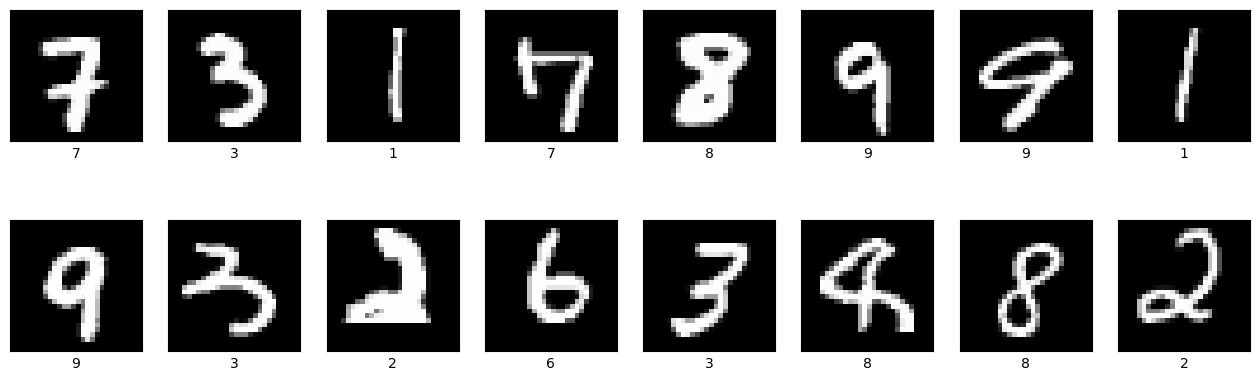

In [125]:
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols, 2.5 * rows))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(train_set))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(train_set[random_index][0].squeeze(0).numpy().reshape([28, 28]), cmap = 'gray')
        ax.set_xlabel(train_set[random_index][1])
plt.show()

Каждая картинка это матрица из чисел. Если число большое - пиксель яркий. Если маленькое - тёмный.

In [126]:
train_set[5][0].shape

torch.Size([1, 28, 28])

Будем прогнозировать тип картинки по её пикселям. Подготовим данные с помощью `DataLoader`. Пока что попробуем настроить его максимально просто. В будущем мы увидим с вами другую магию, на которую способна эта абстракция.

### Задание 7:

Напишите `DataLoader` для тренировочной и тестовой выборок. Попробуйте проитерироваться по нескольким его первым объектам с помощью цикла.

В обучающей выборке данные должны перемешиваться каждую эпоху. Размер батча поставьте равным 64. В тестовой выборке данные перемешивать не надо.

In [127]:
# ваш код  ¯\_(⊙︿⊙)_/¯

### Задание 8:

Напишите  двухслойную полносвязную нейросеть. Выходной слой должен состоять из $10$ нейронов.

In [128]:
class NeuralNet(nn.Module):
    def __init__(self, in_features, num_classes, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            # ваш код  ¯\_(⊙︿⊙)_/¯
        )

    def forward(self, x):
        return self.model(x)

In [129]:
model = NeuralNet(28**2, 10, 20)

Веса моделей хранятся в виде матриц и выглядят так:

In [130]:
[(name, p.shape) for name, p in model.named_parameters()]

[]

Объявляем модель и оптимизатор.

In [131]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCHS = 10

# объявим нейросеть и пошлём её на GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=IMG_SIZE ** 2, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)

# чтобы не писать самим SGD, подгрузим готовый оптимизатор
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# функция потерь
criterion = nn.CrossEntropyLoss() # работает с логитом!


ValueError: optimizer got an empty parameter list

Осталось всё это дело обучить. Для этого нам придётся написать цикл

In [ ]:
from tqdm.notebook import tqdm

# NUM_EPOCHS раз подряд пройдемся по всем батчам из трейна
for epoch in range(NUM_EPOCHS):

    # переключили модель в режим трэйна (важно для батчнорма и дропаута)
    # как минимум эти два слоя при обучении и прогнозировании работают по-разному
    model.train()

    # берем батч из трейн лоадера
    for images, labels in tqdm(train_loader):

        # отправляем тензоры на девайс к сетке
        images = images.to(device)
        labels = labels.to(device)

        ### Пишем самые важные 5 строк
        # зануляем старые градиенты, иначе они сложатся
        optimizer.zero_grad()

        # вызываем модель
        logits = model(torch.flatten(images, start_dim=1))
        # logits: (batch_size, num_classes)

        # считаем функцию потерь
        loss = criterion(logits, labels)

        # считаем градиенты обратным проходом
        loss.backward()

        # обновляем параметры сети (шаг спуска)
        optimizer.step()

    if epoch % 2 == 0:
        mean_val_loss = [] # сюда будем складывать средний лосс по батчам
        val_accuracy = []

        # переключили модель в режим инференса (важно для дропаута и батчнорма)
        model.eval()

        # берем батч из вал лоадера для валидации
        for images, labels in tqdm(test_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)

            # мы считаем качество, поэтому мы запрещаем фреймворку считать
            # градиенты по параметрам, это лишнее, они нам не нужны
            with torch.no_grad():
                # делаем предсказания
                logits = model(torch.flatten(images, start_dim=1))

                # считаем ошибку на валидации
                loss = criterion(logits, labels)

                mean_val_loss.append(loss.cpu().item()) # добавляем в массив
                val_accuracy.extend((torch.argmax(logits, dim=-1) == labels).cpu().numpy().tolist())

        # выводим статистику
        print('Epoch: {epoch}, loss: {loss}, accuracy: {accuracy}'.format(
                epoch=epoch, loss=np.mean(mean_val_loss), accuracy=np.mean(val_accuracy)
        ))


  0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.24500558259570673, accuracy: 0.9315


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 8, loss: 0.08585375701974496, accuracy: 0.9735


  0%|          | 0/938 [00:00<?, ?it/s]

Кажется, что всё работает. Но есть проблемы:

- Мы не нарисовали ни одного графика. Метрики хорошо бы куда-то залоггировать.
- Цикл громоздкий, хорошо бы разбить его на отдельные функции для обучения и валидации. Мы будем его постоянно переписывать и дополнять. Рано или поздно код станет нечитаемым.
- Проблема воспроизводимости. Обучение сильно меняется от запуска к запуску. Возможно, вы один раз получите крутой результат, а потом не сможете его никогда воспроизвести. Это плохо. Чтобы такого не было, надо зафиксировать `seed`.

## 7. Итоговый пайплайн

Для начала постараемся сделать обучение независимым от очередности запуска, воспользуемся советами из официальной статьи [Reproducibilty PyTorch.](https://docs.pytorch.org/docs/stable/notes/randomness.html) Нам необходимо:

- Зафиксировать сид cpu
- Зафиксировать сид gpu
- Зафиксировать сид numpy
- Зафиксировать сид стандартного random

In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # если хочется воспроизводимость на 1000%, надо настроить эту штуку
    # torch.use_deterministic_algorithms(True)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

Эти функции с сидами можно просто копировать в начало своих тетрадок и добавлять в DataLoader.

Теперь напишем функции для обучения.

In [ ]:
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    """Одна эпоха обучения"""
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    """Прогнозы на валидации"""

    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(torch.flatten(images, start_dim=1))
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy


def train(model, optimizer, criterion, train_loader, test_loader, num_epochs, scheduler=None):
    """Обучение модели"""

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # функция для смены lr по расписанию
        if scheduler is not None:
            scheduler.step()

        plot_losses(train_losses, val_losses, train_accuracies, val_accuracies)

In [ ]:
g = set_global_seed(42)

train_set = MNIST('.MNIST', transform=T.ToTensor(), train=True, download=True)
val_set = MNIST('.MNIST', transform=T.ToTensor(), train=False, download=True)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size     = 256,
    shuffle        = True,
    num_workers    = 0,
    worker_init_fn = seed_worker,
    generator      = g
)

test_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size    = 4096,
    shuffle       = False,
    num_workers   = 0
)

In [ ]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=IMG_SIZE**2, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH)

Добавим в обучение смену LR по расписанию.

In [ ]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=IMG_SIZE**2, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH, scheduler=scheduler)

Теперь воспроизводимость и удобство нам обеспечены. Тем не менее, в этом коде всё ещё много чего не хватает.

Во-первых, логгировать эксперименты можно куда удобнее. Во-вторых, хорошо бы делать чекпойнты и сохранять лучшие версии модели по мере обучения, чтобы впоследствии их не потерять. На логгирование мы посмотрим ниже, а чекпойнты вам предстоит научиться делать в домашке.

## 8. Логгирование экспериментов

Вместо того, чтобы каждый раз самим рисовать графики в `matplotlib`, можно красиво трекать метрики в полуавтоматическом режиме в [WandB.](https://docs.wandb.ai/)

**Зачем это надо:**

Обычно, при обучении моделей надо ставить большое количество экспериментов. Это делает команда из кучи людей. Очень удобно залоггировать всё в одно место и дальше сравнивать разные запуски моделей между собой. Для этого есть довольно много разных сервисов. На наш взгляд WandB один из самых удачных.

Для этого регистрируемся на сайте, устанавливаем и логинимся. Пробуем запустить [туториал со стартовой тетрадкой.](https://docs.wandb.ai/tutorials/pytorch/)

> Официально с 12 сентября 2024 года, данная библиотека может не работать на территории РФ, поэтому расчехляем VPN не только для ютуба.

In [ ]:
!pip install wandb -qU

In [ ]:
import wandb
wandb.login()

Функции `training_epoch` и `validation_epoch` из раздела 7 не меняются. Меняется только `train`: вместо `plot_losses` метрики каждой эпохи уходят в трекер через функцию `log(metrics, epoch)`. Так один и тот же цикл обучения работает с любым сервисом — ниже подключим два.

In [ ]:
def train(model, optimizer, criterion, train_loader, test_loader, num_epochs, scheduler=None, log=None):
    """Обучение модели с логированием метрик через log(metrics, epoch)"""

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        metrics = {
            "loss/train": train_loss,
            "loss/val": val_loss,
            "accuracy/train": train_accuracy,
            "accuracy/val": val_accuracy,
        }
        if log is not None:
            log(metrics, epoch)


def new_run():
    """Свежие модель, оптимизатор и scheduler — по одному набору на каждый прогон"""
    model = NeuralNet(in_features=IMG_SIZE ** 2, num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)
    return model, optimizer, scheduler

In [ ]:
IMG_SIZE = 28
NUM_CLASSES = 10
HIDDEN_SIZE = 64
NUM_EPOCH = 10
LR = 0.01

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

In [ ]:
wandb.init(
    project="my-first-nn-project",
    name="FCN + CosineAnnealingLR",
    config={
        "architecture": "FCN",
        "learning_rate": LR,
        "hidden_size": HIDDEN_SIZE,
        "epochs": NUM_EPOCH,
        "dataset": "MNIST",
        "optimizer": "SGD",
        "scheduler": "CosineAnnealingLR",
    },
)

model, optimizer, scheduler = new_run()
train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH, scheduler=scheduler,
      log=lambda metrics, epoch: wandb.log(metrics, step=epoch))

wandb.finish()

### Альтернатива: ClearML

Тот же принцип, другой сервис — [ClearML](https://clear.ml) (hosted-версия на app.clear.ml, бесплатный тариф, пока что работает из России, езли запускать локально (из Colab Wandb запускается нормально)). Три объекта: `Task` — один прогон, `task.connect(...)` — гиперпараметры во вкладку Configuration, `logger.report_scalar(title, series, value, iteration)` — кривые: `title` — график, `series` — линия на нём. Одинаковые названия у разных прогонов — и UI наложит их кривые друг на друга.

Ключи: Settings → Workspace → Create new credentials. Вводим их через `getpass`, чтобы они не остались в ноутбуке. Потренироваться без аккаунта можно с `Task.set_offline(True)` перед `Task.init` — всё запишется локально.

In [ ]:
!pip install clearml -qU

In [ ]:
from clearml import Task
from getpass import getpass

Task.set_credentials(
    api_host="https://api.clear.ml",
    web_host="https://app.clear.ml",
    files_host="https://files.clear.ml",
    key=getpass("ClearML access key: "),
    secret=getpass("ClearML secret key: "),
)

In [ ]:
task = Task.init(project_name="my-first-nn-project", task_name="FCN + CosineAnnealingLR",
                 reuse_last_task_id=False)   # иначе перезапуск с тем же именем перезапишет прошлый прогон
task.connect({"learning_rate": LR, "hidden_size": HIDDEN_SIZE, "epochs": NUM_EPOCH,
              "optimizer": "SGD", "scheduler": "CosineAnnealingLR"}, name="config")
logger = task.get_logger()


def log_clearml(metrics, epoch):
    for name, value in metrics.items():
        title, series = name.split("/")        # "loss/train" -> график loss, линия train
        logger.report_scalar(title, series, value, epoch)


model, optimizer, scheduler = new_run()
train(model, optimizer, criterion, train_loader, test_loader, NUM_EPOCH, scheduler=scheduler, log=log_clearml)

task.close()